<a href="https://colab.research.google.com/github/carolynee01/receding-hairline/blob/main/receding_hairline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Przygotowanie środowiska i danych

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tworzymy strukturę folderów zgodną z wymaganiami projektu
if not os.path.exists('data'):
    os.makedirs('data/zakola')
    os.makedirs('data/brak_zakoli')

print("Środowisko przygotowane.")

Środowisko przygotowane.


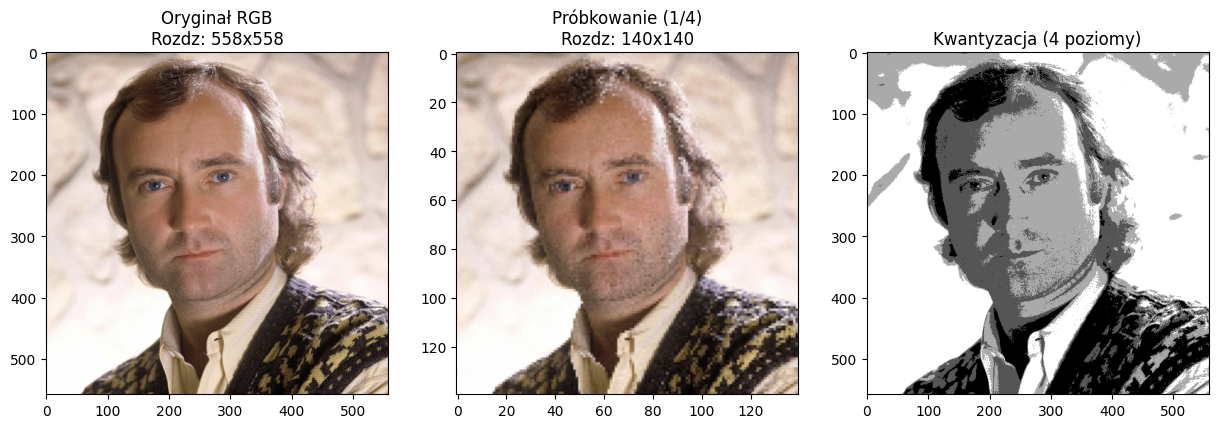

In [2]:
# 1. Wczytanie obrazu
# Na potrzeby przykładu użyjemy przykładowego zdjęcia
img_path = 'data/Phil Collins.png'
img_bgr = cv2.imread(img_path)

if img_bgr is not None:
    # 2. Konwersja między przestrzeniami barw
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # 3. Dyskretyzacja: Próbkowanie (zmniejszenie rozdzielczości)
    # Próbkowanie co 4 piksel (downsampling)
    sampling_factor = 4
    img_sampled = img_rgb[::sampling_factor, ::sampling_factor]

    # 4. Dyskretyzacja: Kwantyzacja (zmniejszenie liczby poziomów jasności)
    # Redukcja do 4 poziomów (2 bity) zamiast 256 (8 bitów)
    levels = 4
    img_quantized = np.floor_divide(img_gray, 256//levels) * (256//levels)

    # 5. Wizualizacja i opis parametrów
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f"Oryginał RGB\nRozdz: {img_rgb.shape[1]}x{img_rgb.shape[0]}")

    plt.subplot(1, 3, 2)
    plt.imshow(img_sampled)
    plt.title(f"Próbkowanie (1/{sampling_factor})\nRozdz: {img_sampled.shape[1]}x{img_sampled.shape[0]}")

    plt.subplot(1, 3, 3)
    plt.imshow(img_quantized, cmap='gray')
    plt.title(f"Kwantyzacja ({levels} poziomy)")

    plt.show()
else:
    print("Błąd: Nie znaleziono pliku obrazu.")

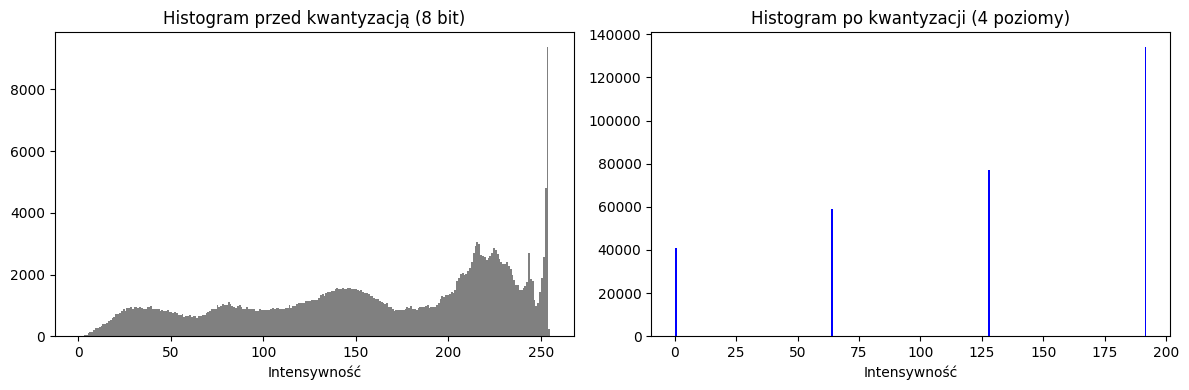

In [3]:
def plot_histograms(before, after):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(before.ravel(), bins=256, color='gray')
    plt.title("Histogram przed kwantyzacją (8 bit)")
    plt.xlabel("Intensywność")

    plt.subplot(1, 2, 2)
    plt.hist(after.ravel(), bins=256, color='blue')
    plt.title(f"Histogram po kwantyzacji ({levels} poziomy)")
    plt.xlabel("Intensywność")

    plt.tight_layout()
    plt.show()

if img_bgr is not None:
    plot_histograms(img_gray, img_quantized)

In [ ]:
import kagglehub
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")